In [1]:
from __future__ import annotations
import random,math,torch,numpy as np,matplotlib.pyplot as plt
import fastcore.all as fc
from functools import partial

from miniai.datasets import *
from miniai.learner import *

In [2]:
import torch.nn.functional as F,matplotlib as mpl
from pathlib import Path
from operator import attrgetter,itemgetter
from contextlib import contextmanager

from torch import tensor,nn,optim
import torchvision.transforms.functional as TF
from datasets import load_dataset

from fastcore.test import test_close

torch.set_printoptions(precision=2, linewidth=140, sci_mode=False)
mpl.rcParams['figure.constrained_layout.use'] = True

import logging
logging.disable(logging.WARNING)

c:\Users\grzeg\Miniconda3\envs\fastai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def set_seed(seed, deterministic=False):
    torch.use_deterministic_algorithms(deterministic)
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

In [4]:
x,y = 'image','label'
name = "fashion_mnist"
dsd = load_dataset(name)
bs = 1024

@inplace
def transformi(b): b[x] = [TF.to_tensor(o) for o in b[x]]

tds = dsd.with_transform(transformi)
dls = DataLoaders.from_dd(tds, bs)
dt = dls.train

In [25]:
ig = itemgetter(*tds["train"].features)
ig

operator.itemgetter('image', 'label')

# Baseline

In [37]:
def conv(ni, nf, ks=3, act=True):
    res = nn.Conv2d(ni, nf, stride=2, kernel_size=ks, padding=ks//2)
    if act: res = nn.Sequential(res, nn.ReLU())
    return res

def cnn_layers():
    return [
        conv(1 ,8, ks=5),        #14x14
        conv(8 ,16),             #7x7
        conv(16,32),             #4x4
        conv(32,64),             #2x2
        conv(64,10, act=False),  #1x1
        nn.Flatten()]

In [38]:
from torcheval.metrics import MulticlassAccuracy

In [39]:
metrics = MetricsCB(accuracy=MulticlassAccuracy())
cbs = [TrainCB(), DeviceCB(), metrics, ProgressCB(plot=True)]

In [40]:
def fit(model, epochs=1, xtra_cbs=None):
    learn = Learner(model, dls, loss_func=F.cross_entropy, lr=0.6, cbs=cbs+fc.L(xtra_cbs))
    learn.fit(epochs)
    return learn

accuracy,loss,epoch,train
0.160,2.300,0,train
0.199,2.124,0,eval


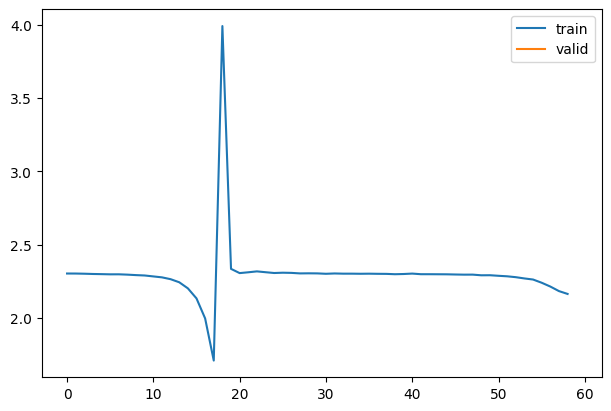

In [41]:
set_seed(1)
learn = fit(nn.Sequential(*cnn_layers()))

We want to understand why the model is not traning properly. For that we want to collect some data from inner layers of the model. We want to have means and standard deviations of activations in each layer.

# Manual insertion

In [10]:
class SequentialModel(nn.Module):
    def __init__(self, *layers):
        super().__init__()
        self.layers = nn.ModuleList(layers)
        self.act_means = [[] for _ in layers]
        self.act_stds  = [[] for _ in layers]
        
    def __call__(self, x):
        for i,l in enumerate(self.layers):
            x = l(x)
            self.act_means[i].append(to_cpu(x).mean())
            self.act_stds [i].append(to_cpu(x).std ())
        return x
    
    def __iter__(self): return iter(self.layers)

accuracy,loss,epoch,train
0.160,2.300,0,train
0.199,2.124,0,eval


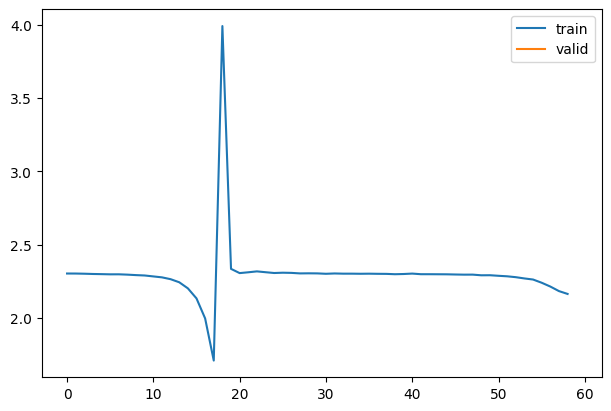

In [11]:
set_seed(1)
model = SequentialModel(*cnn_layers())
learn = fit(model)

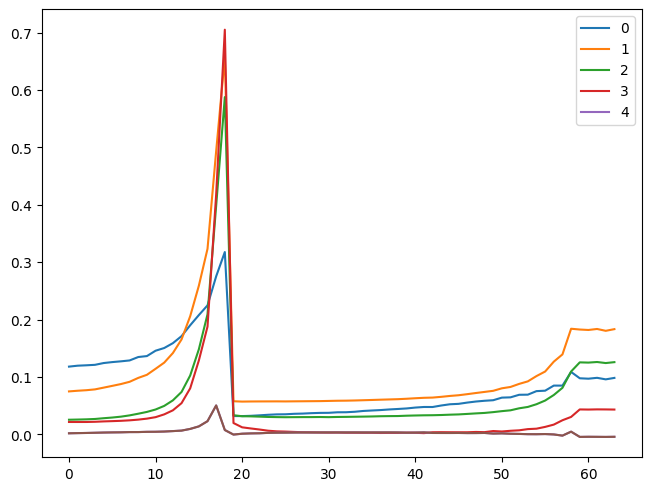

In [12]:
for l in model.act_means: plt.plot(l)
plt.legend(range(5));

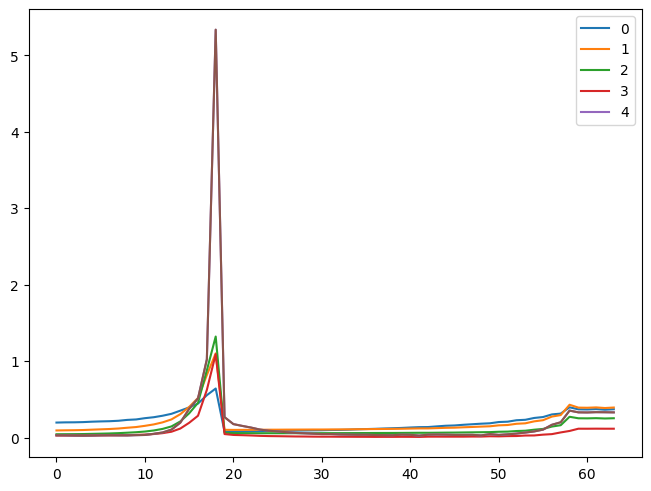

In [13]:
for l in model.act_stds: plt.plot(l)
plt.legend(range(5));

# Pytorch hooks

Hooks are PyTorch object you can add to any nn.Module. A hook will be called when a layer, it is registered to, is executed during the forward pass (forward hook) or the backward pass (backward hook). Hooks don't require us to rewrite the model.

In [14]:
set_seed(1)
model = nn.Sequential(*cnn_layers())

In [15]:
act_means = [[] for _ in model]
act_stds  = [[] for _ in model]

def append_stats(i, mod, inp, outp):
    act_means[i].append(to_cpu(outp).mean())
    act_stds [i].append(to_cpu(outp).std())

In [16]:
for i,m in enumerate(model):
    print(i, m)

0 Sequential(
  (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (1): ReLU()
)
1 Sequential(
  (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (1): ReLU()
)
2 Sequential(
  (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (1): ReLU()
)
3 Sequential(
  (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (1): ReLU()
)
4 Conv2d(64, 10, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
5 Flatten(start_dim=1, end_dim=-1)


In [17]:
for i,m in enumerate(model): m.register_forward_hook(partial(append_stats, i))

accuracy,loss,epoch,train
0.160,2.300,0,train
0.199,2.124,0,eval


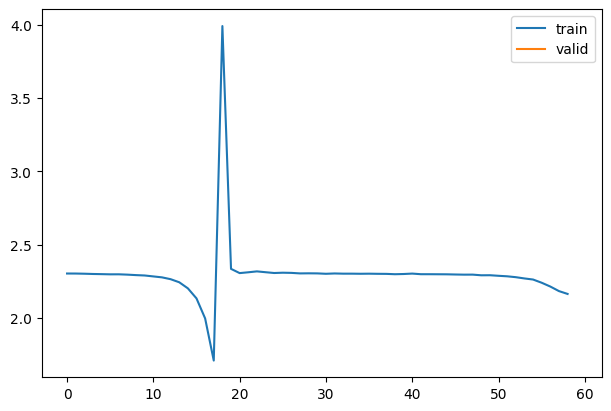

In [18]:
fit(model)

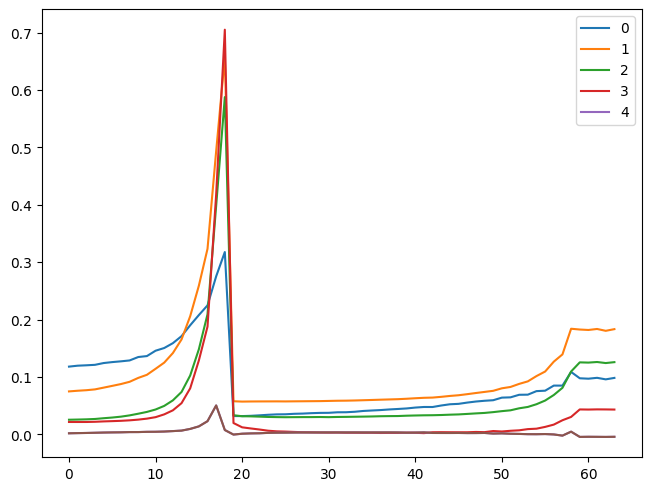

In [19]:
for o in act_means: plt.plot(o)
plt.legend(range(5));

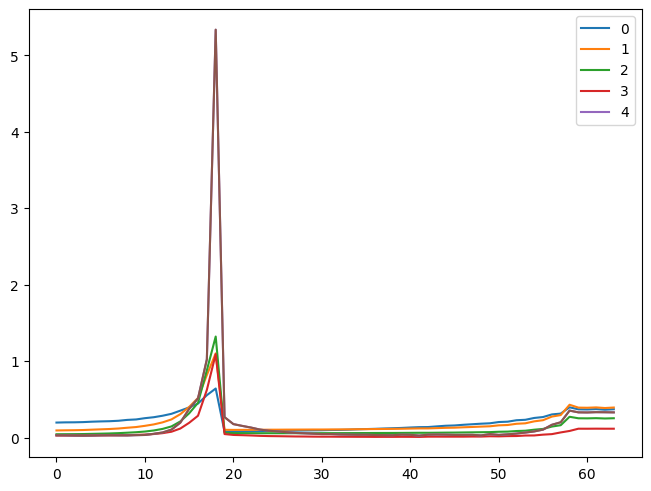

In [20]:
for o in act_stds: plt.plot(o)
plt.legend(range(5));

# Hook class

In [21]:
class Hook():
    def __init__(self, m, f): self.hook = m.register_forward_hook(partial(f, self))
    def remove(self): self.hook.remove()
    def __del__(self): self.remove()

In [22]:
def append_stats(hook, mod, inp, outp):
    if not hasattr(hook,'stats'): hook.stats = ([],[])
    acts = to_cpu(outp)
    hook.stats[0].append(acts.mean())
    hook.stats[1].append(acts.std())

In [23]:
set_seed(1)
model = nn.Sequential(*cnn_layers())

In [24]:
hooks = [Hook(l, append_stats) for l in model[:5].children()]

accuracy,loss,epoch,train
0.160,2.300,0,train
0.199,2.124,0,eval


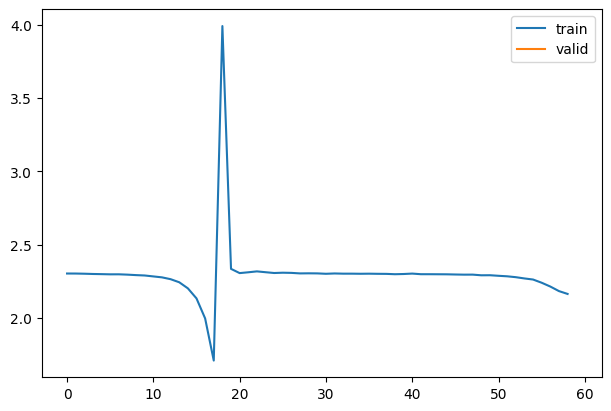

In [25]:
learn = fit(model)

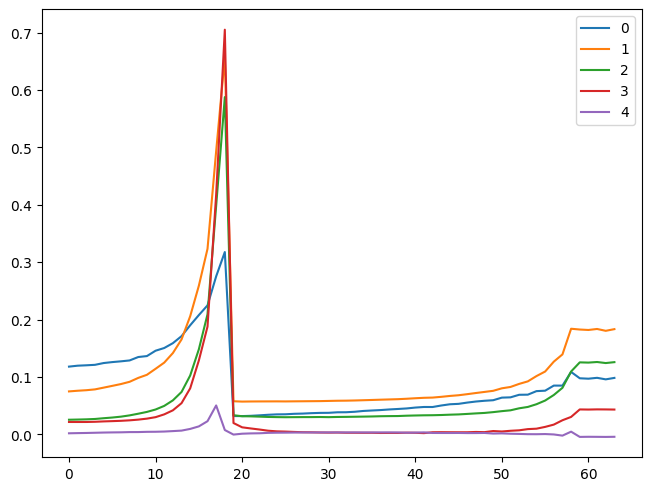

In [26]:
for h in hooks:
    plt.plot(h.stats[0])
    h.remove()
plt.legend(range(5));

In [27]:
class Hooks(list):
    def __init__(self, ms, f): super().__init__([Hook(m, f) for m in ms])
    def __enter__(self, *args): return self
    def __exit__ (self, *args): self.remove()
    def __del__(self): self.remove()
    def __delitem__(self, i):
        self[i].remove()
        super().__delitem__(i)
    def remove(self):
        for h in self: h.remove()

In [28]:
set_seed(1)
model = nn.Sequential(*cnn_layers())

accuracy,loss,epoch,train
0.160,2.300,0,train
0.199,2.124,0,eval


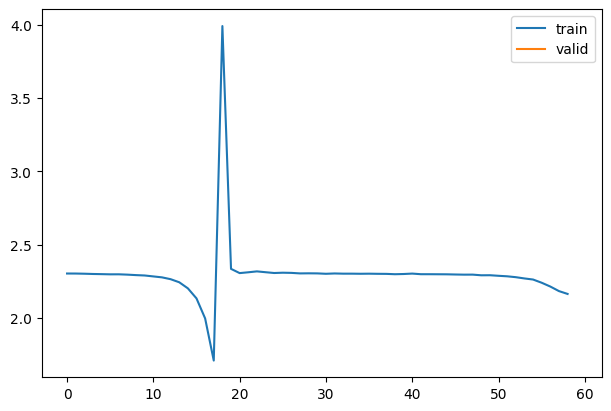

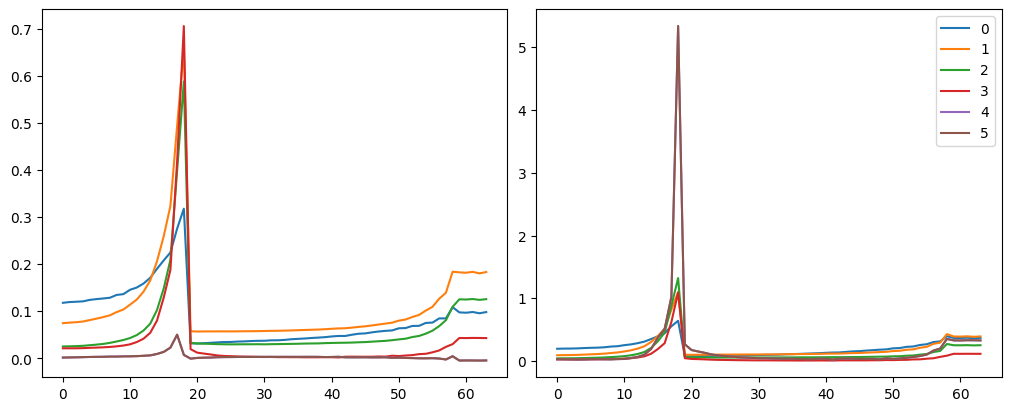

In [29]:
with Hooks(model, append_stats) as hooks:
    fit(model)
    fig,axs = plt.subplots(1,2, figsize=(10,4))
    for h in hooks:
        for i in 0,1: axs[i].plot(h.stats[i])
    plt.legend(range(6));

# HooksCallback

In [30]:
class HooksCallback(Callback):
    def __init__(self, hookfunc, mod_filter=fc.noop, on_train=True, on_valid=False, mods=None):
        fc.store_attr()
        super().__init__()
    
    def before_fit(self, learn):
        if self.mods: mods=self.mods
        else: mods = fc.filter_ex(learn.model.modules(), self.mod_filter)
        self.hooks = Hooks(mods, partial(self._hookfunc, learn)) # like a list of hooks

    def _hookfunc(self, learn, *args, **kwargs):
        if (self.on_train and learn.training) or (self.on_valid and not learn.training): self.hookfunc(*args, **kwargs)

    def after_fit(self, learn): self.hooks.remove()
    def __iter__(self): return iter(self.hooks)
    def __len__(self): return len(self.hooks)

In [31]:
set_seed(1)
model = nn.Sequential(*cnn_layers())

In [32]:
cov2d_filter = fc.risinstance(nn.Conv2d)
mod_0cov2d = model[0][0]

print(mod_0cov2d)
cov2d_filter(mod_0cov2d)

Conv2d(1, 8, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))


True

In [33]:
list(filter(cov2d_filter, model.modules()))

[Conv2d(1, 8, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2)),
 Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1)),
 Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1)),
 Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1)),
 Conv2d(64, 10, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))]

In [34]:
list(fc.filter_ex(model.modules(), cov2d_filter))

[Conv2d(1, 8, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2)),
 Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1)),
 Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1)),
 Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1)),
 Conv2d(64, 10, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))]

In [35]:
hc = HooksCallback(append_stats, mod_filter=fc.risinstance(nn.Conv2d))

accuracy,loss,epoch,train
0.160,2.300,0,train
0.199,2.124,0,eval


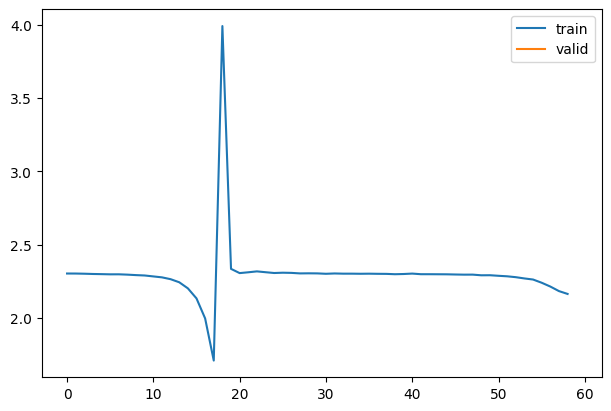

In [36]:

fit(model, xtra_cbs=[hc]);

In [37]:
len(hc)

5

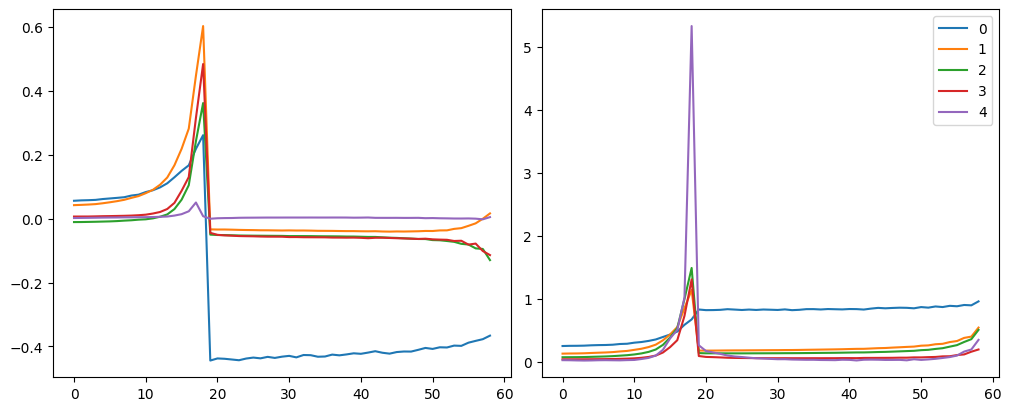

In [38]:
fig,axs = plt.subplots(1,2, figsize=(10,4))
for h in hc:
    for i in 0,1: axs[i].plot(h.stats[i])
plt.legend(range(6));

# Histograms

In [39]:
a = torch.randn(100) * 10
print(a.max())
b = a.abs().histc(40,0,a.max())
b

tensor(26.57)


tensor([3., 2., 6., 3., 6., 5., 4., 9., 3., 7., 5., 1., 5., 4., 6., 1., 2., 2., 6., 3., 2., 1., 0., 1., 1., 1., 1., 1., 1., 3., 1., 0., 2.,
        0., 1., 0., 0., 0., 0., 1.])

In [40]:
torch.stack([b]*100).t().float()

tensor([[3., 3., 3.,  ..., 3., 3., 3.],
        [2., 2., 2.,  ..., 2., 2., 2.],
        [6., 6., 6.,  ..., 6., 6., 6.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 1., 1., 1.]])

In [41]:
torch.log1p(tensor([0,1,2,3]))

tensor([0.00, 0.69, 1.10, 1.39])

In [42]:
c = torch.stack([b]*100).t().float().log1p()
c

tensor([[1.39, 1.39, 1.39,  ..., 1.39, 1.39, 1.39],
        [1.10, 1.10, 1.10,  ..., 1.10, 1.10, 1.10],
        [1.95, 1.95, 1.95,  ..., 1.95, 1.95, 1.95],
        ...,
        [0.00, 0.00, 0.00,  ..., 0.00, 0.00, 0.00],
        [0.00, 0.00, 0.00,  ..., 0.00, 0.00, 0.00],
        [0.69, 0.69, 0.69,  ..., 0.69, 0.69, 0.69]])

<Axes: >

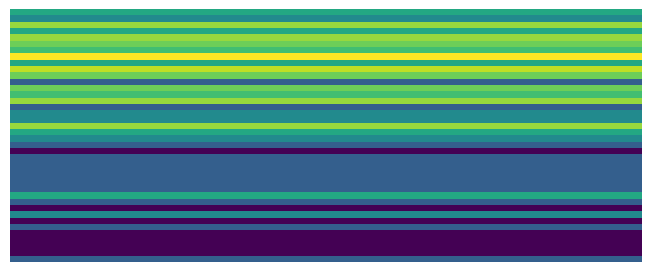

In [43]:
show_image(c)

<Axes: >

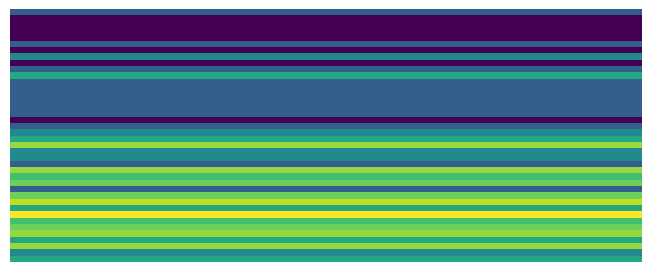

In [44]:
show_image(c, origin='lower') # we want to have bins close to zero, close to x-axis

In [45]:
def append_stats(hook, mod, inp, outp):
    if not hasattr(hook,'stats'): hook.stats = ([],[],[])
    acts = to_cpu(outp)
    hook.stats[0].append(acts.mean())
    hook.stats[1].append(acts.std())
    hook.stats[2].append(acts.abs().histc(40,0,10))

In [46]:
f = fc.risinstance(nn.Conv2d)
print(f)
print(f(1))
print(fc.risinstance(nn.Conv2d, 1))

functools.partial(<function _risinstance at 0x000002116E8547C0>, (<class 'torch.nn.modules.conv.Conv2d'>,))
False
False


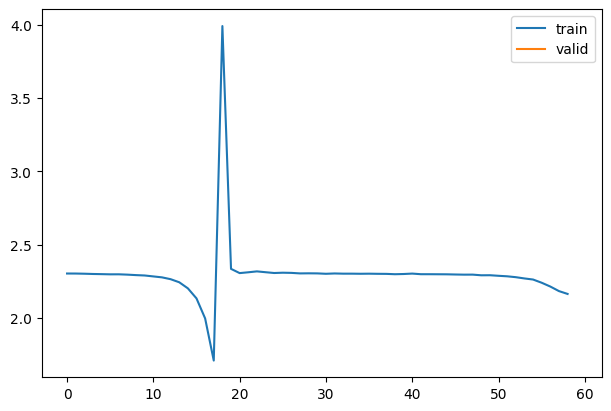

In [47]:
set_seed(1)
model = nn.Sequential(*cnn_layers())
hc = HooksCallback(append_stats, mod_filter=fc.risinstance(nn.Conv2d))
fit(model, xtra_cbs=[hc]);

In [48]:
def get_hist(h): return torch.stack(h.stats[2]).t().float().log1p()

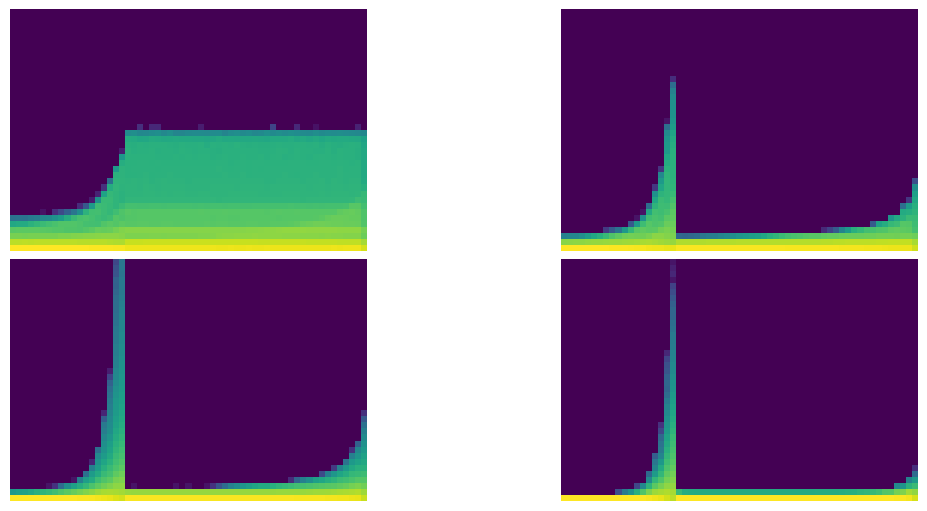

In [49]:

fig,axes = get_grid(len(hc), figsize=(11,5))
for ax,h in zip(axes.flat, hc):
    show_image(get_hist(h), ax, origin='lower')

In [50]:
def get_min(h):
    h1 = torch.stack(h.stats[2]).t().float()
    return h1[0]/h1.sum(0)

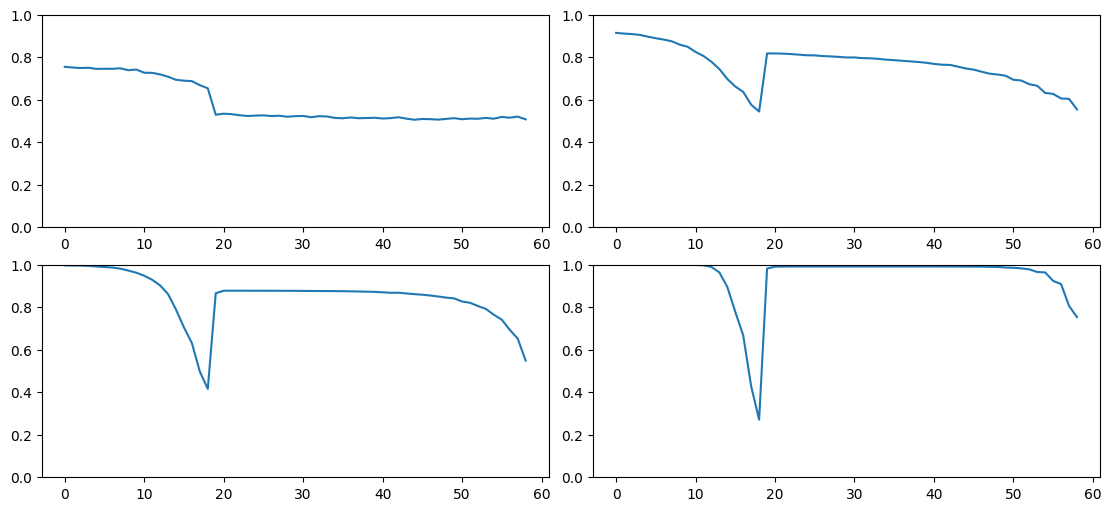

In [51]:

fig,axes = get_grid(len(hc), figsize=(11,5))
for ax,h in zip(axes.flatten(), hc):
    ax.plot(get_min(h))
    ax.set_ylim(0,1)

# ActivationStats

In [52]:
class ActivationStats(HooksCallback):
    def __init__(self, mod_filter=fc.noop): super().__init__(append_stats, mod_filter)

    def color_dim(self, figsize=(11,5)):
        fig,axes = get_grid(len(self), figsize=figsize)
        for ax,h in zip(axes.flat, self):
            show_image(get_hist(h), ax, origin='lower')

    def dead_chart(self, figsize=(11,5)):
        fig,axes = get_grid(len(self), figsize=figsize)
        for ax,h in zip(axes.flatten(), self):
            ax.plot(get_min(h))
            ax.set_ylim(0,1)

    def plot_stats(self, figsize=(10,4)):
        fig,axs = plt.subplots(1,2, figsize=figsize)
        for h in self:
            for i in 0,1: axs[i].plot(h.stats[i])
        axs[0].set_title('Means')
        axs[1].set_title('Stdevs')
        plt.legend(fc.L.range(self))

In [53]:
astats = ActivationStats(fc.risinstance(nn.Conv2d))

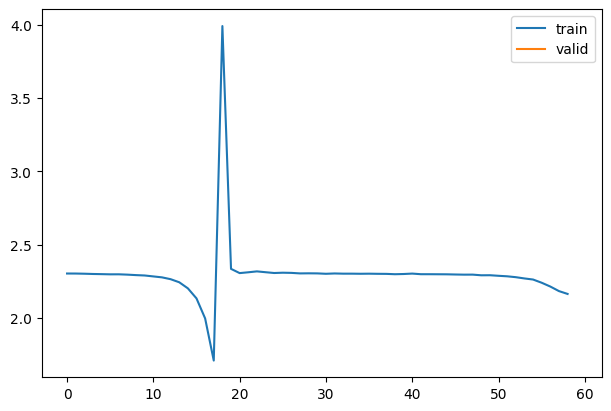

In [54]:
set_seed(1)
model = nn.Sequential(*cnn_layers())
fit(model, xtra_cbs=[astats]);

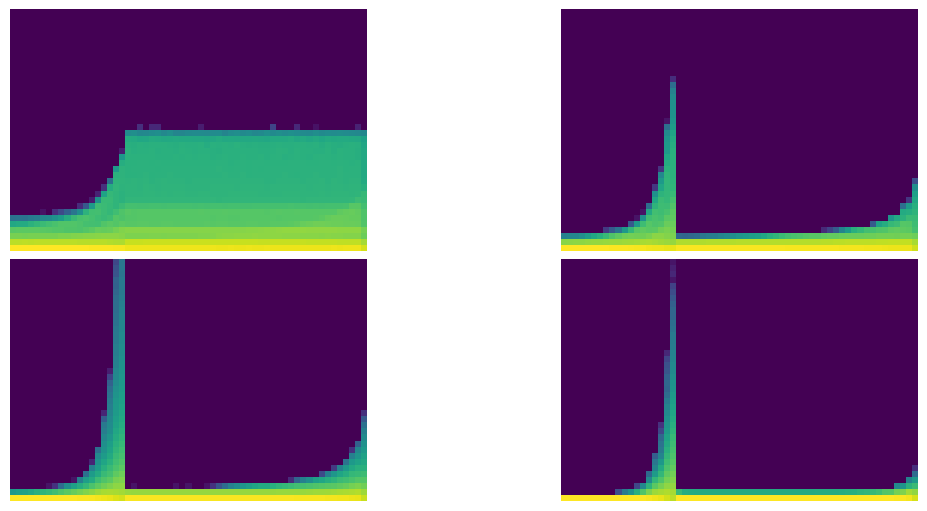

In [55]:
astats.color_dim()

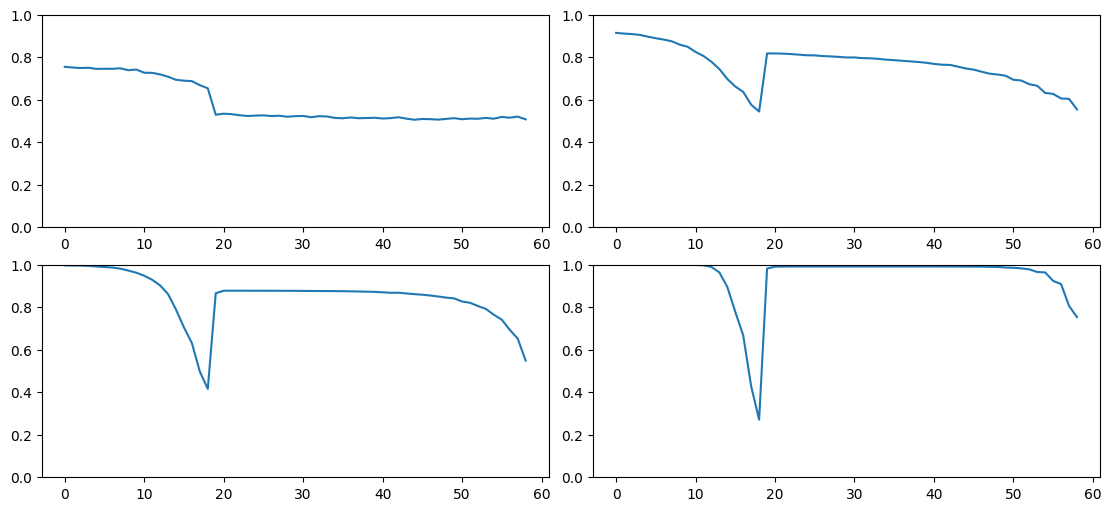

In [56]:
astats.dead_chart()

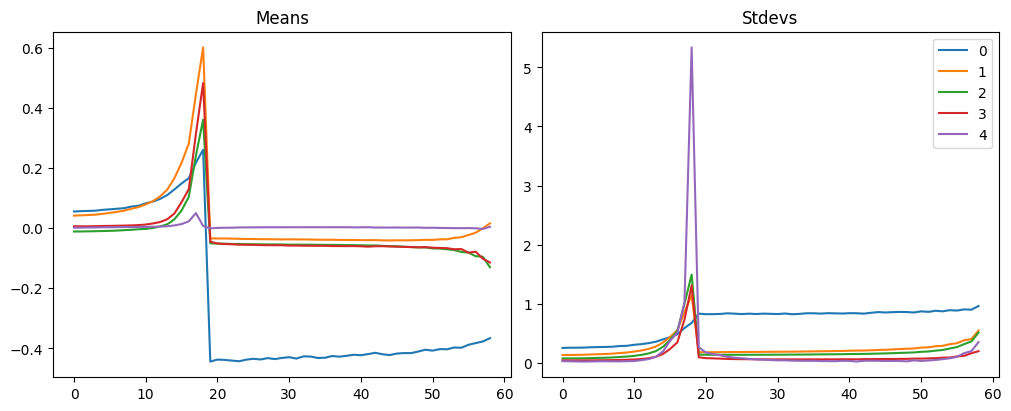

In [57]:
astats.plot_stats()